# Import, Load, and Understand the Data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 1. Load the primary dataset
df = pd.read_csv("synthetic_insurance_claims_research_calibrated.csv")

# 2. Display metadata and shape
print(f"Initial dataset shape: {df.shape}")
display(df.head())
df.info()

# 3. Quick metrics check
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
display(df.describe())

Initial dataset shape: (25040, 8)


,Claim_ID,Claim_Amount,Policy_Age,Claim_Frequency,Location,Claimant_History,Processing_Time,Investigation_Status
0,CLM011056,66115.50,60.0,1.0,West,Previous Claims,9.37,0
1,CLM006776,157524.28,39.0,2.0,South,Multiple Previous Claims,23.98,0
2,CLM021203,84682.45,81.0,2.0,West,Previous Claims,19.77,0
3,CLM013682,27019.97,60.0,1.0,North,Clean,33.74,0
4,CLM024455,16851.54,40.0,0.0,West,Clean,18.55,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25040 entries, 0 to 25039
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Claim_ID              25040 non-null  object 
 1   Claim_Amount          24890 non-null  float64
 2   Policy_Age            24840 non-null  float64
 3   Claim_Frequency       24865 non-null  float64
 4   Location              24890 non-null  object 
 5   Claimant_History      24865 non-null  object 
 6   Processing_Time       24890 non-null  float64
 7   Investigation_Status  25040 non-null  int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 1.5+ MB
Missing values per column:
 Claim_ID                  0
Claim_Amount            150
Policy_Age              200
Claim_Frequency         175
Location                150
Claimant_History        175
Processing_Time         150
Investigation_Status      0
dtype: int64

Duplicate rows: 40


,Claim_Amount,Policy_Age,Claim_Frequency,Processing_Time,Investigation_Status
count,2.489000e+04,24840.000000,24865.000000,24890.000000,25040.000000
mean,8.805181e+04,52.467633,1.362397,28.678671,0.054992
std,7.364934e+04,33.574552,1.571897,15.763090,0.227969
min,-4.902078e+03,-21.000000,0.000000,2.000000,0.000000
25%,4.137721e+04,28.000000,0.000000,17.970000,0.000000
50%,6.791739e+04,45.000000,1.000000,25.460000,0.000000
75%,1.106638e+05,70.000000,2.000000,35.490000,0.000000
max,1.250000e+06,180.000000,14.000000,220.650000,1.000000


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


# Clean the Data


In [3]:
# Preserve initial shape information
initial_rows = len(df)

# 1. Remove duplicates
df = df.drop_duplicates()

# 2. Replace invalid categorical values with NaN
valid_locations = ['North', 'South', 'East', 'West', 'Central']
df.loc[~df['Location'].isin(valid_locations), 'Location'] = np.nan

valid_histories = ['Clean', 'Previous Claims', 'Multiple Previous Claims', 'Prior Investigation']
df.loc[~df['Claimant_History'].isin(valid_histories), 'Claimant_History'] = np.nan

# 3. Handle negative values
df.loc[df['Claim_Amount'] < 0, 'Claim_Amount'] = np.nan
df.loc[df['Policy_Age'] < 0, 'Policy_Age'] = np.nan

# 4. Fill missing values
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])
df['Claimant_History'] = df['Claimant_History'].fillna(df['Claimant_History'].mode()[0])

df['Claim_Amount'] = df['Claim_Amount'].fillna(df['Claim_Amount'].median())
df['Policy_Age'] = df['Policy_Age'].fillna(df['Policy_Age'].median())
df['Claim_Frequency'] = df['Claim_Frequency'].fillna(df['Claim_Frequency'].median())
df['Processing_Time'] = df['Processing_Time'].fillna(df['Processing_Time'].median())

# Cleaned output details
print(f"Rows removed: {initial_rows - len(df)}")
print(f"New dataset shape: {df.shape}")
print("Remaining missing values:", df.isnull().sum().sum())

Rows removed: 40
New dataset shape: (25000, 8)
Remaining missing values: 0


# Target Distribution & Basic EDA


In [4]:
# Target variable distribution
counts = df["Investigation_Status"].value_counts()
percentages = df["Investigation_Status"].value_counts(normalize=True) * 100

print("Investigation Status Counts:\n", counts)
print("\nInvestigation Status Percentages:\n", percentages)

# Group variables by status
display(df.groupby('Investigation_Status')[['Claim_Amount', 'Policy_Age', 'Claim_Frequency', 'Processing_Time']].mean())

Investigation Status Counts:
 Investigation_Status
0    23625
1     1375
Name: count, dtype: int64

Investigation Status Percentages:
 Investigation_Status
0    94.5
1     5.5
Name: proportion, dtype: float64


,Claim_Amount,Policy_Age,Claim_Frequency,Processing_Time
Investigation_Status,,,,
0,84895.307745,52.441524,1.117503,28.093798
1,140900.749062,52.357091,5.523636,38.393560


# Exactly 3 Main Visualizations


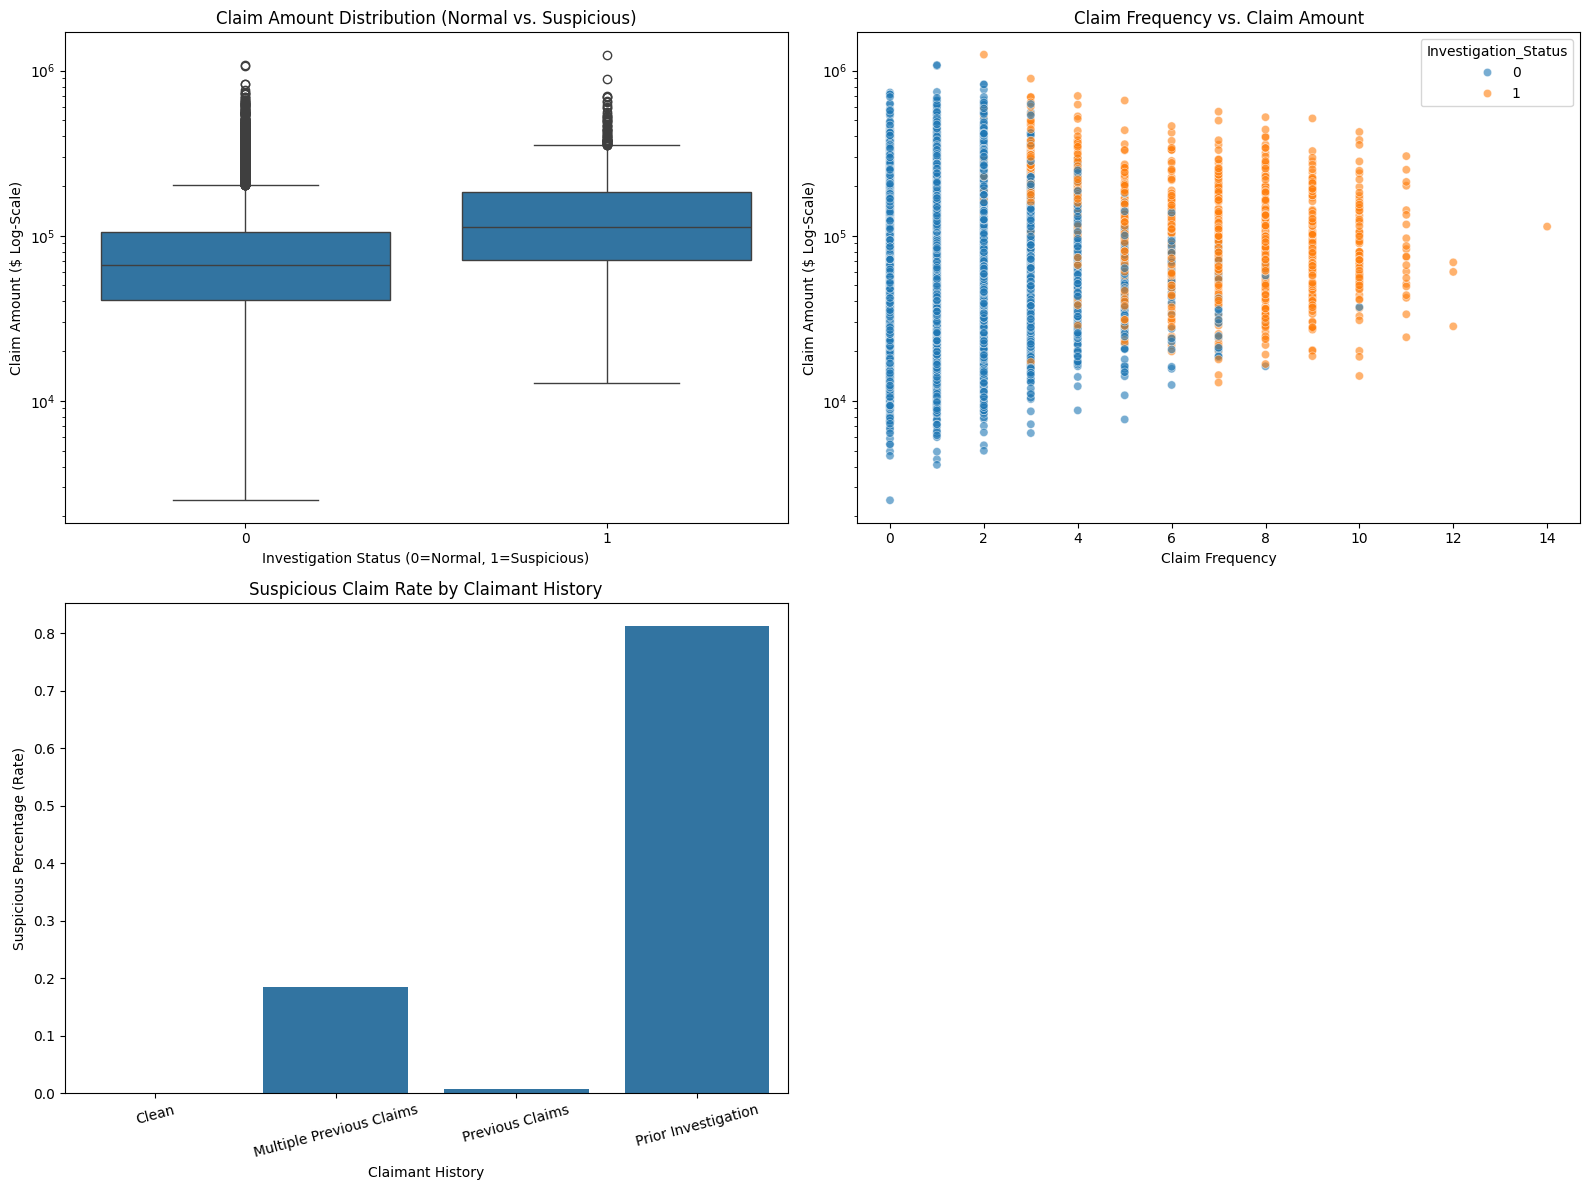

In [5]:
plt.figure(figsize=(16, 12))

# Visualization 1: Claim Amount Distribution by Investigation Status
plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='Investigation_Status', y='Claim_Amount')
plt.yscale('log')
plt.title('Claim Amount Distribution (Normal vs. Suspicious)')
plt.xlabel('Investigation Status (0=Normal, 1=Suspicious)')
plt.ylabel('Claim Amount ($ Log-Scale)')

# Visualization 2: Claim Frequency vs. Claim Amount by Status
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='Claim_Frequency', y='Claim_Amount', hue='Investigation_Status', alpha=0.6)
plt.yscale('log')
plt.title('Claim Frequency vs. Claim Amount')
plt.xlabel('Claim Frequency')
plt.ylabel('Claim Amount ($ Log-Scale)')

# Visualization 3: Suspicious Claim Percentage by Claimant History
plt.subplot(2, 2, 3)
rate_by_history = df.groupby('Claimant_History')['Investigation_Status'].mean().reset_index()
sns.barplot(data=rate_by_history, x='Claimant_History', y='Investigation_Status')
plt.title('Suspicious Claim Rate by Claimant History')
plt.xlabel('Claimant History')
plt.ylabel('Suspicious Percentage (Rate)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

* **Plot 1**: Suspicious claims tend to skew higher on average in claim amounts than normal claims.
* **Plot 2**: Higher claim frequencies accompanied by large claim amounts exhibit higher concentrations of suspicious cases.
* **Plot 3**: Prior Investigations are highly associated with suspicious flags compared to claimants with 'Clean' histories.

# Prepare Data, Convert Categorical and Train/Test Split


In [6]:
# Drop index columns and isolate target
X = df.drop(columns=['Claim_ID', 'Investigation_Status'])
y = df['Investigation_Status']

# One-hot encoding
X = pd.get_dummies(X, columns=['Location', 'Claimant_History'], drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (20000, 11), X_test shape: (5000, 11)


Train Random Forest & Make Predictions


In [7]:
# Initialize model with class balancing
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Basic evaluations
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9778
Precision: 0.8628
Recall: 0.7091
F1 Score: 0.7784
ROC-AUC: 0.9769

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      4725
           1       0.86      0.71      0.78       275

    accuracy                           0.98      5000
   macro avg       0.92      0.85      0.88      5000
weighted avg       0.98      0.98      0.98      5000



Let's draw the Confusion Matrix as a heatmap.

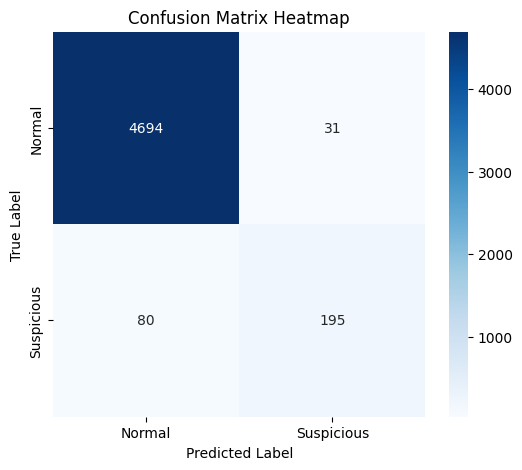

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Suspicious'], yticklabels=['Normal', 'Suspicious'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# False Positive Analysis


In [9]:
TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()
fpr = FP / (FP + TN)

print(f"True Negatives: {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives: {FN}")
print(f"True Positives: {TP}")
print(f"False Positive Rate: {fpr:.4%}")

True Negatives: 4694
False Positives (FP): 31
False Negatives: 80
True Positives: 195
False Positive Rate: 0.6561%


# Feature Importance


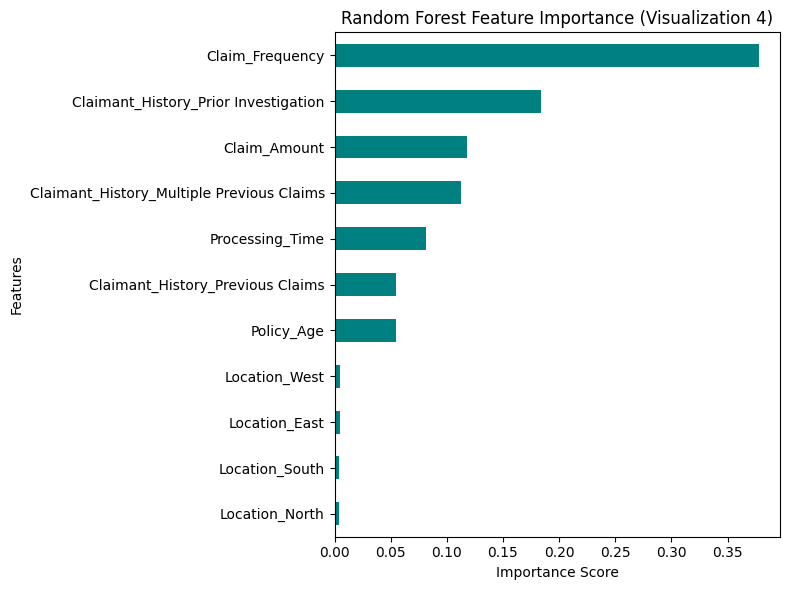

In [10]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importance.plot(kind='barh', color='teal')
plt.title('Random Forest Feature Importance (Visualization 4)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Prioritized Investigation List


In [11]:
# Calculate probability on full encoded dataset
full_probs = model.predict_proba(X)[:, 1]

# Create risk table
priority_df = pd.DataFrame({
    'Claim_ID': df['Claim_ID'],
    'Risk_Probability': full_probs
})

# Categorize based on rules
def get_priority(prob):
    if prob >= 0.70:
        return 'High'
    elif prob >= 0.40:
        return 'Medium'
    else:
        return 'Low'

priority_df['Investigation_Priority'] = priority_df['Risk_Probability'].apply(get_priority)
priority_sorted = priority_df.sort_values(by='Risk_Probability', ascending=False)

# Top 20 claims displayed
display(priority_sorted.head(20))

,Claim_ID,Risk_Probability,Investigation_Priority
16608,CLM019453,1.0,High
18801,CLM000984,1.0,High
14163,CLM008975,1.0,High
18196,CLM023796,1.0,High
24941,CLM007209,1.0,High
18795,CLM009217,1.0,High
10593,CLM003022,1.0,High
2244,CLM014972,1.0,High
5163,CLM007139,1.0,High
4710,CLM013846,1.0,High


In [12]:
results_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'False Positives', 'False Negatives', 'False Positive Rate'],
    'Result': [f"{acc:.4f}", f"{prec:.4f}", f"{rec:.4f}", f"{f1:.4f}", f"{roc_auc:.4f}", str(FP), str(FN), f"{fpr:.4%}"]
})
display(results_table)

,Metric,Result
0,Accuracy,0.9778
1,Precision,0.8628
2,Recall,0.7091
3,F1 Score,0.7784
4,ROC-AUC,0.9769
5,False Positives,31
6,False Negatives,80
7,False Positive Rate,0.6561%
